In [12]:
import pandas as pd
import os

# This path tells the computer to look inside your Windows Downloads folder
downloads_path = os.path.expanduser('~/Downloads/walmart.csv/train.csv')

# Load the file from that exact path location
df = pd.read_csv(downloads_path)

# Show the first 5 rows to make sure it opened!
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [13]:
# 1. Tell the computer that the date column is a real calendar date line
df['Date'] = pd.to_datetime(df['Date'])

# 2. Make the date column the primary index axis on the far left
df.set_index('Date', inplace=True)

# 3. Sort the table from the oldest calendar day to the newest day
df.sort_index(inplace=True)

# 4. Let's look at our beautifully updated table!
df.head()

,Store,Dept,Weekly_Sales,IsHoliday
Date,,,,
2010-02-05,1,1,24924.50,False
2010-02-05,29,5,15552.08,False
2010-02-05,29,6,3200.22,False
2010-02-05,29,7,10820.05,False
2010-02-05,29,8,20055.64,False


In [14]:
# 1. Create a brand new column just for the Year
df['Year'] = df.index.year

# 2. Create a brand new column for the Month (1 for Jan, 2 for Feb... up to 12)
df['Month'] = df.index.month

# 3. Create a brand new column for the Day of the month (1 to 31)
df['Day'] = df.index.day

# 4. Let's look at our table now to see our new columns!
df.head()

,Store,Dept,Weekly_Sales,IsHoliday,Year,Month,Day
Date,,,,,,,
2010-02-05,1,1,24924.50,False,2010,2,5
2010-02-05,29,5,15552.08,False,2010,2,5
2010-02-05,29,6,3200.22,False,2010,2,5
2010-02-05,29,7,10820.05,False,2010,2,5
2010-02-05,29,8,20055.64,False,2010,2,5


In [15]:
# Create a brand new column for the Day of the Week (0 to 6)
df['DayOfWeek'] = df.index.dayofweek

# Let's look at our table now to see our newest column!
df.head()

,Store,Dept,Weekly_Sales,IsHoliday,Year,Month,Day,DayOfWeek
Date,,,,,,,,
2010-02-05,1,1,24924.50,False,2010,2,5,4
2010-02-05,29,5,15552.08,False,2010,2,5,4
2010-02-05,29,6,3200.22,False,2010,2,5,4
2010-02-05,29,7,10820.05,False,2010,2,5,4
2010-02-05,29,8,20055.64,False,2010,2,5,4


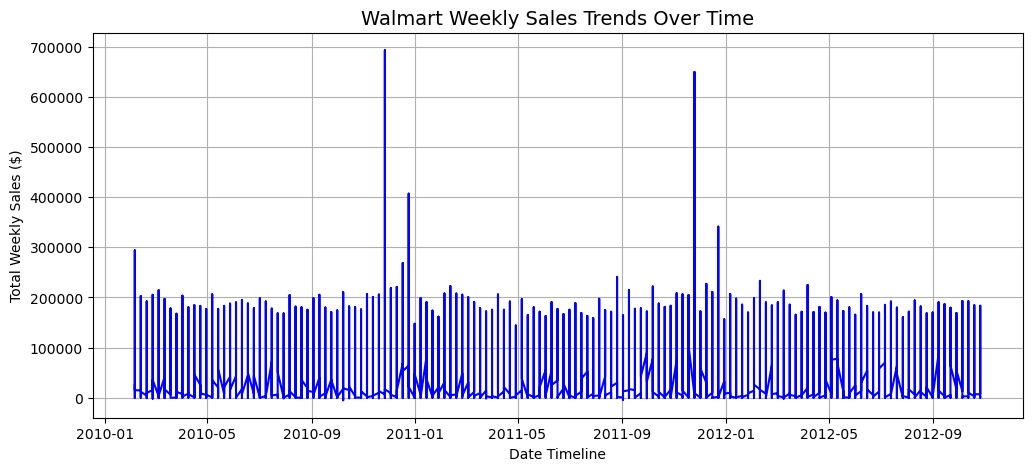

In [16]:
import matplotlib.pyplot as plt

# 1. Tell the computer how big to make our graph window
plt.figure(figsize=(12, 5))

# 2. Draw a line graph using our table's 'Weekly_Sales' column
plt.plot(df['Weekly_Sales'], color='blue', linewidth=1.5)

# 3. Add labels and a title so our chart is easy to read
plt.title('Walmart Weekly Sales Trends Over Time', fontsize=14)
plt.xlabel('Date Timeline')
plt.ylabel('Total Weekly Sales ($)')
plt.grid(True)

# 4. Show the completed chart on the screen!
plt.show()

In [22]:
import pandas as pd
import os

# 1. Use your working folder path to open the file
downloads_path = os.path.expanduser('~/Downloads/walmart.csv/train.csv')
df = pd.read_csv(downloads_path)

# 2. Convert the 'Date' column (with a capital D) to real calendar timestamps
df['Date'] = pd.to_datetime(df['Date'])

# 3. Set the 'Date' column as the primary far-left index
df.set_index('Date', inplace=True)

# 4. Sort the table chronologically from oldest to newest
df.sort_index(inplace=True)

# 5. Recreate all 4 of your custom feature clue columns
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.dayofweek

# 6. Check the index properties to see our success message
print(df.index)

DatetimeIndex(['2010-02-05', '2010-02-05', '2010-02-05', '2010-02-05',
               '2010-02-05', '2010-02-05', '2010-02-05', '2010-02-05',
               '2010-02-05', '2010-02-05',
               ...
               '2012-10-26', '2012-10-26', '2012-10-26', '2012-10-26',
               '2012-10-26', '2012-10-26', '2012-10-26', '2012-10-26',
               '2012-10-26', '2012-10-26'],
              dtype='datetime64[ns]', name='Date', length=421570, freq=None)


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. Select the updated "Clues" (X) and the "Target" we want to predict (y)
features = ['Store', 'IsHoliday', 'Year', 'Month', 'Day', 'DayOfWeek']
X = df[features]
y = df['Weekly_Sales']

# 2. Split the data: 80% for the AI to study, 20% to test its skills later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize our Random Forest AI Model
# (Using 20 estimators keeps it quick for this initial test run)
model = RandomForestRegressor(n_estimators=20, random_state=42)

print("Training the AI model now... Please wait a moment...")
# 4. Tell the AI to study the data!
model.fit(X_train, y_train)

print("AI Training Complete! Let's see how smart it is...")
# 5. Make predictions on our test data
predictions = model.predict(X_test)

# 6. Calculate the average mistake amount (MAE)
mae = mean_absolute_error(y_test, predictions)
print(f"On average, the AI's predictions are off by: ${mae:,.2f}")

Training the AI model now... Please wait a moment...
AI Training Complete! Let's see how smart it is...
On average, the AI's predictions are off by: $14,461.90


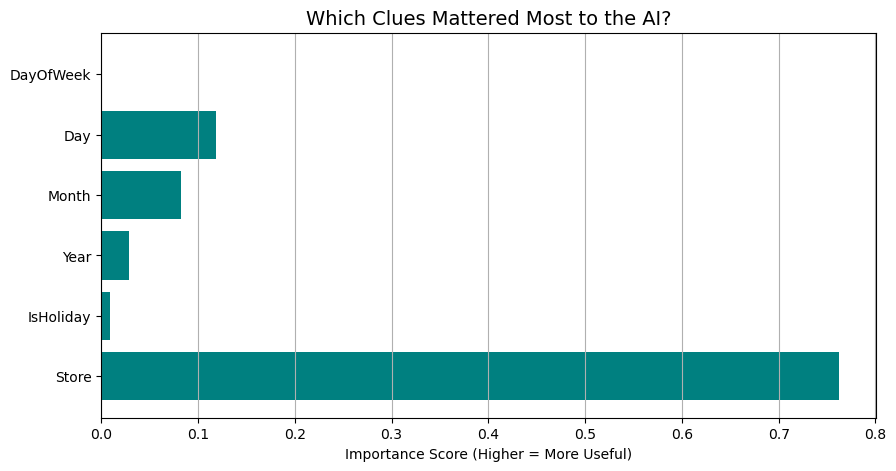

In [25]:
import matplotlib.pyplot as plt

# 1. Grab the importance scores from our trained model
importances = model.feature_importances_

# 2. Match them up with our feature names
feature_names = ['Store', 'IsHoliday', 'Year', 'Month', 'Day', 'DayOfWeek']

# 3. Create a bar chart
plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances, color='teal')
plt.xlabel('Importance Score (Higher = More Useful)')
plt.title('Which Clues Mattered Most to the AI?', fontsize=14)
plt.grid(axis='x')

# 4. Show the chart
plt.show()